In [1]:
import ab_pentagonCluster as ab
import numpy as np
import os

In [ ]:
n_vec = np.append([20],np.arange(24,151,2))
#result = np.zeros((77,len(n_vec)))
result = np.loadtxt("partitions_result.csv", delimiter = ",")
n_start = 24 + (result.shape[1] - 2) * 2 + 2
for n in range(n_start,151,2):
    print(str(n)+ " begin...")
    result = np.append(result, np.transpose(ab.partition_freq(n)).reshape((77,1)),axis = 1)
    np.savetxt("partitions_result.csv", result, delimiter=",")
    print(str(n)+" done.")

In [22]:
iso_list = np.append([20],np.arange(24,401,2)).reshape(190,1)
temp = np.array([1,1,1,2,3,6,6,15,17,40,45,89,116,199,271,437,580,924,1205,1812,2385,3465,4478,6332,8149,11190,14246,19151,
        24109,31924,39718,51592,63761,81738,99918,126409,153493,191839,231017,285914,341658,419013,497529,604217,713319,
        860161,1008444,1207119,1408553,1674171,1942929,2295721,2650866,3114236,3580637,4182071,4787715,5566949,6344698,
        7341204,8339033,9604411,10867631,12469092,14059174,16066025,18060979,20558767,23037594,26142839,29202543,33022573,
        36798433,41478344,46088157,51809031,57417264,64353269,71163452,79538751,87738311,97841183,107679717,119761075,
        131561744,145976674,159999462,177175687,193814658,214127742,233846463,257815889,281006325,309273526,336500830,
        369580714,401535955,440216206,477420176,522599564,565900181,618309598,668662698,729414880,787556069,857934016,
        925042498,1006016526,1083451816,1176632247,1265323971,1372440782,1474111053,1596482232,1712934069,1852762875,
        1985250572,2144943655,2295793276,2477017558,2648697036,2854536850,3048609900,3282202941,3501931260,3765465341,
        4014007928,4311652376,4591045471,4926987377,5241548270,5618445787,5972426835,6395981131,6791769082,7267283603,
        7710782991,8241719706,8738236515,9332065811,9884604767,10548218751,11164542762,11902015724,12588998862,13410330482,
        14171344797,15085164571,15930619304,16942010457,17880232383,19002055537,20037346408,21280571390,22426253115,
        23796620378,25063227406,26577912084,27970034826,29642262229,31177474996,33014225318,34705254287,36728266430,
        38580626759,40806395661,42842199753,45278616586,47513679057,50189039868,52628839448,55562506886,58236270451,
        61437700788,64363670678,67868149215,71052718441,74884539987,78364039771,82532990559,86329680991,90881152117,
        95001297565,99963147805,104453597992,109837310021,114722988623,120585261143,125873325588,132247999328]).reshape(190,1)
temp.shape
iso_list = np.append(iso_list,temp,axis=1)
np.savetxt("iso_list.csv", iso_list, delimiter = ",")

In [3]:
import itertools
path_database = "/Volumes/StochaExt/fullerene_database/buckygen"

def partition_analysis(n, block_size = 10**5):
    m = int(n / 2 + 2)
    iso_list = np.loadtxt("iso_list.csv", delimiter = ",")
    iso = int(iso_list[np.where(iso_list[:,0] == n)[0],1][0])
    pt = ab.partitions(12)
    
    #If the readible file does not exist yet, run the planarread algorithm
    if not os.path.exists(path_database + "/C" + str(n) + "_dual_read"):
        ab.run_bucky_planarread(n,True,True)
    path = path_database + "/C" + str(n) + "_dual_read"

    #Compute the number of blocks
    num_blocks = int(iso / block_size)
    #Compute the frequency of pentagonal clusters for every block and sum them up at the end
    result_matrix = np.zeros(77)
    
    print("Data avaiable....")
    for b in range(num_blocks):
        with open(path_database + "/C" + str(n) + "_dual_read") as f_in:
            block = np.genfromtxt(itertools.islice(f_in, b * block_size * m, (b + 1) * block_size * m), 
                                  dtype = float, usecols = (0,1,2,3,4,5))
        
            #Build the adjancency matrices for this block and save them in a tensor
            A_block_tensor = np.zeros((m,m,block_size))
            for i in range(block_size):
                A = block[i*m:(i+1)*m,:]
                for j in range(m):
                    for col in range(6):
                        if A[j,col] != 0:
                            A_block_tensor[j,int(A[j,col]-1),i] = 1
            result_block = np.zeros(pt.shape[0])
            for i in range(block_size):
                result_block[ab.find_partition(ab.pentagon_cluster(A_block_tensor[:,:,i]),pt)] += 1
    
            #Store the block result into the matrix
            result_matrix += result_block
            print(str((b+1)/(num_blocks+1)) + "% done.")
            
    rem_block_size = iso - block_size * num_blocks
    with open(path_database + "/C" + str(n) + "_dual_read") as f_in:
        rem_block = np.genfromtxt(itertools.islice(f_in, num_blocks * block_size * m, iso * m), 
                                  dtype = float, usecols = (0,1,2,3,4,5))
        #Build the adjancency matrices for this block and save them in a tensor
        A_block_tensor = np.zeros((m,m,rem_block_size))
        for i in range(rem_block_size):
            A = rem_block[i*m:(i+1)*m,:]
            for j in range(m):
                for col in range(6):
                    if A[j,col] != 0:
                        A_block_tensor[j,int(A[j,col]-1),i] = 1
        result_block = np.zeros(pt.shape[0])
        for i in range(rem_block_size):
            result_block[ab.find_partition(ab.pentagon_cluster(A_block_tensor[:,:,i]),pt)] += 1
    
        #Store the block result into the matrix
        result_matrix += result_block
    return result_matrix


In [ ]:
partition_result = np.loadtxt("partitions_result.csv",delimiter = ",")
n = 150
partition_result = np.append(partition_result,partition_analysis(n, block_size = 10**4).reshape((77,1)),axis=1)
np.savetxt("partitions_result.csv", partition_result ,delimiter = ",")
print(str(n) + " done.")

#c150_partitions = partition_analysis(n, block_size)
#np.savetxt("partitionC" + str(n) + ".csv", results, delimiter = ",")

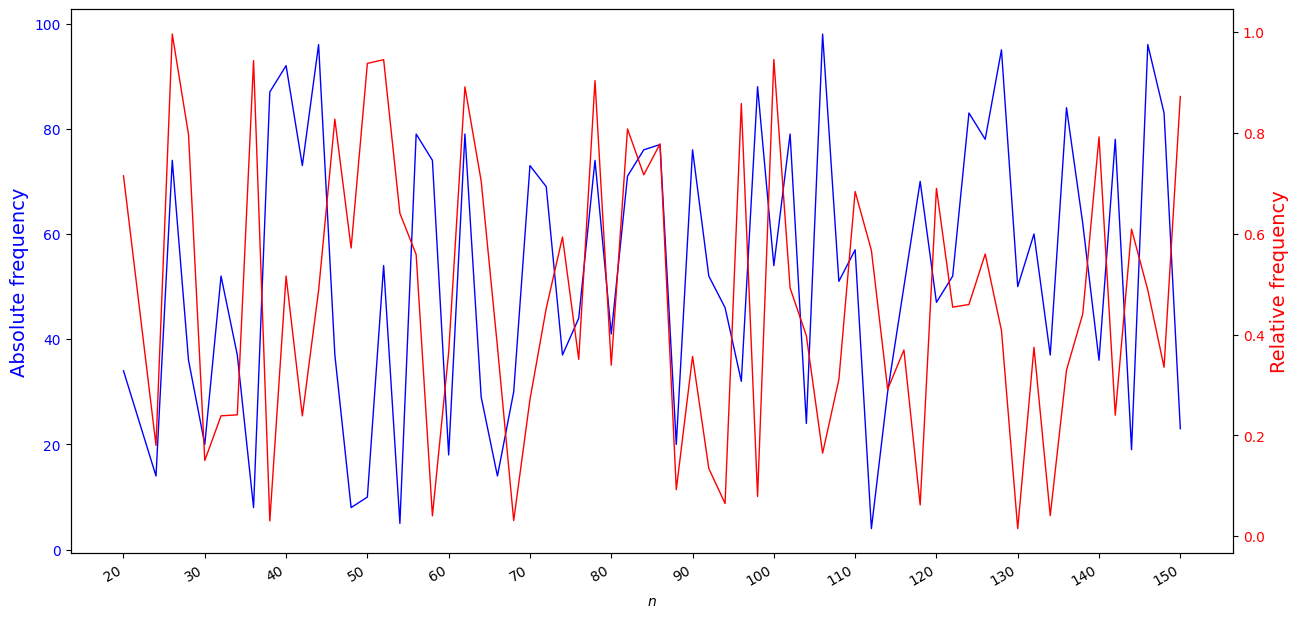

In [168]:
import matplotlib.pyplot as plt

n_vec = np.append([20],np.arange(24,151,2))
abs_freq = np.random.randint(0,100,n_vec.shape)
rel_freq = np.random.uniform(size = n_vec.shape)

COLOR_TEMPERATURE = "blue"
COLOR_PRICE = "red"

fig, ax1 = plt.subplots(figsize=(15, 8))
ax2 = ax1.twinx()

ax1.plot(n_vec, abs_freq, color=COLOR_TEMPERATURE, lw=1)
ax2.plot(n_vec, rel_freq, color=COLOR_PRICE, lw=1)

ax1.set_xlabel(r"$n$")
ax1.set_ylabel("Absolute frequency", color=COLOR_TEMPERATURE, fontsize=14)
ax1.tick_params(axis="y", labelcolor=COLOR_TEMPERATURE)

ax2.set_ylabel("Relative frequency", color=COLOR_PRICE, fontsize=14)
ax2.tick_params(axis="y", labelcolor=COLOR_PRICE)

#fig.suptitle("Temperature down, price up", fontsize=20)
fig.autofmt_xdate()
plt.xticks(np.arange(20,151,10))
plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [7]:
x = np.arange(1,13).reshape((4,3))
print(x)
y = 

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
